# Exercises XP: Introduction to LLMs

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells containing **TODO** markers need your input.


## 👩‍🏫👩🏿‍🏫 What you’ll learn
- Understand what Large Language Models (LLMs) can do.
- Review the Transformer architecture and the tokenization pipeline.
- Differentiate between pretraining and fine-tuning.
- Generate text with a pretrained language model.


## 🛠️ What you will create
- Markdown answers describing key NLP concepts.
- Python code that loads GPT-2 (or a similar causal LM) and performs basic tokenization and generation.


> **Learning point**
> Work through the exercises sequentially. Run installation cells only once, then focus on filling each TODO before executing the corresponding code.


## 🌟 Exercise 1 · What are Large Language Models?


### 1.1 Define LLMs
TODO: Explain in your own words what LLMs are and what kinds of tasks they are designed to solve.


### 1.1 Define LLMs

**TODO:** Large Language Models (LLMs) are a type of artificial intelligence model designed to understand and generate human language. They are trained on vast amounts of text data, allowing them to learn complex patterns, grammar, and semantic relationships within language. LLMs are designed to solve various natural language processing (NLP) tasks, including:

*   **Text Generation:** Creating coherent and contextually relevant text, such as articles, stories, and code.
*   **Translation:** Translating text from one language to another.
*   **Summarization:** Condensing long texts into shorter, digestible summaries.
*   **Question Answering:** Providing answers to questions based on given text or general knowledge.
*   **Sentiment Analysis:** Determining the emotional tone or sentiment expressed in a piece of text.
*   **Chatbots and Conversational AI:** Engaging in human-like conversations.
*   **Code Generation:** Generating programming code based on natural language descriptions.

### 1.2 Prefilled · install core libraries
Run once to install `transformers`, `torch`, and supporting utilities exactly as in the enoncé.


In [1]:
%pip install --quiet transformers matplotlib --upgrade


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 44.4 MB/s eta 0:00:00


### 1.3 Load GPT for causal text generation
Reuse the snippet from the platform: declare the model name, tokenizer, and model weights.


In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

model_name = "gpt2"  # GPT-2 is used here for demonstration; can be replaced with models like "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)   # Load AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)       # Load AutoModelForCausalLM.from_pretrained(model_name)

if None in (model_name, tokenizer, model):
    raise ValueError("Fill in model_name, tokenizer, and model before continuing.")

print(f"\nModel '{model_name}' loaded successfully!")
print("""
GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.
""")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


Model 'gpt2' loaded successfully!

GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.



## 🌟 Exercise 2 · Transformer Architecture and Tokenization


TODO: Describe the tokenization process in your own words before coding.


### 2.1 Explain Tokenization

**TODO:** Tokenization is the process of breaking down a continuous sequence of text into smaller units called tokens. These tokens can be words, subwords, or even individual characters, depending on the tokenization strategy. For LLMs, tokenization is a crucial preprocessing step because models operate on numerical representations rather than raw text. Each unique token is assigned a unique numerical ID, forming a vocabulary.

There are several common tokenization approaches:

*   **Word-based tokenization:** Splits text into words. Simple, but struggles with out-of-vocabulary (OOV) words and different forms of the same word.
*   **Character-based tokenization:** Splits text into individual characters. Handles OOV words well but results in very long sequences and doesn't capture semantic meaning efficiently.
*   **Subword tokenization (e.g., Byte Pair Encoding (BPE), WordPiece, SentencePiece):** This is the most common approach for LLMs. It breaks down words into smaller, frequently occurring subword units. This approach effectively balances vocabulary size with the ability to handle OOV words by decomposing them into known subwords. For example, 'unhappiness' might be tokenized as 'un', 'happy', 'ness'.

Original Text: Large Language Models are revolutionizing AI.
Tokens: ['Large', 'ĠLanguage', 'ĠModels', 'Ġare', 'Ġrevolution', 'izing', 'ĠAI', '.']
Token IDs: [21968, 15417, 32329, 389, 5854, 2890, 9552, 13]


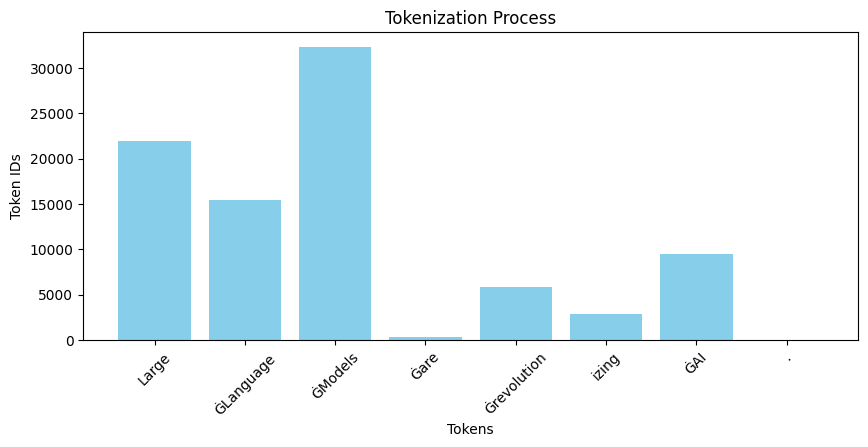

In [3]:
text = "Large Language Models are revolutionizing AI."  # TODO: provide a sentence of your choice
if text is None:
    raise ValueError("Define the variable `text` with a short sentence.")

tokens = tokenizer.tokenize(text)         # TODO: tokenize the input
token_ids = tokenizer.convert_tokens_to_ids(tokens)  # TODO: convert to ids

print(f"Original Text: {text}")
print(f"Tokens: {tokens}")
print(f"Token IDs: {token_ids}")

x_label = "Tokens"  # TODO: label for the x-axis (e.g., "Tokens")
y_label = "Token IDs"  # TODO: label for the y-axis (e.g., "Token IDs")
title = "Tokenization Process"    # TODO: chart title

if None in (x_label, y_label, title):
    raise ValueError("Set x_label, y_label, and title before plotting.")

plt.figure(figsize=(10, 4))
plt.bar(tokens, token_ids, color="skyblue")
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
plt.xticks(rotation=45)
plt.show()

## 🌟 Exercise 3 · Token IDs and special prefixes


In [4]:
if 'tokens' not in globals() or 'token_ids' not in globals():
    raise ValueError("Run Exercise 2 to define `tokens` and `token_ids` first.")

# TODO: print the token along with its numeric id
for token, token_id in zip(tokens, token_ids):
    print(f"Token: '{token}', ID: {token_id}")

Token: 'Large', ID: 21968
Token: 'ĠLanguage', ID: 15417
Token: 'ĠModels', ID: 32329
Token: 'Ġare', ID: 389
Token: 'Ġrevolution', ID: 5854
Token: 'izing', ID: 2890
Token: 'ĠAI', ID: 9552
Token: '.', ID: 13


TODO: In plain language, explain what the `Ġ` prefix indicates in GPT-style vocabularies.


### 3.1 Special Prefixes

**TODO:** In GPT-style tokenizers (specifically those using Byte Pair Encoding or BPE, like GPT-2), the `Ġ` prefix (which represents a unicode character U+0120, a Latin Capital Letter G with a dot above) indicates that the token is the beginning of a new word.

Here's why it's used:

*   **Subword Tokenization:** BPE works by breaking down words into subword units. For example, 'tokenization' might be broken into 'token', 'iz', 'ation'.
*   **Distinguishing Full Words:** When the tokenizer encounters a space, it treats the subsequent characters as the start of a new word. To differentiate between subword tokens that are part of a larger word and those that start a new word, the `Ġ` prefix is added to tokens that follow a space.
*   **Reconstruction:** This allows the model to accurately reconstruct the original text from the token IDs. Without it, it would be ambiguous whether a token like `Language` was a standalone word or part of `somethingLanguage`.

In essence, `Ġ` means "this token starts a word, and there was a space before it in the original text."

## 🌟 Exercise 4 : Pretraining vs. Fine-Tuning

**TODO:** Large Language Models typically undergo two major phases of training: Pretraining and Fine-Tuning.

### Pretraining

**Description:** Pretraining is the initial, resource-intensive phase where a large language model is trained on a massive, diverse dataset of text and code (e.g., billions of words from the internet, books, articles, etc.). The goal is for the model to learn general language understanding, grammar, facts, and common sense. During pretraining, the model typically learns to predict the next word in a sequence (causal language modeling) or fill in masked words (masked language modeling).

**Characteristics:**
*   **Scale:** Involves enormous datasets and computational power.
*   **Goal:** Learn broad language patterns and representations.
*   **Output:** A general-purpose language model with a wide range of capabilities but not specialized for any particular task.

### Fine-Tuning

**Description:** Fine-tuning is the subsequent phase where a pretrained model is adapted to a specific downstream task or domain. This involves training the pretrained model on a smaller, task-specific dataset with labeled examples. The model's weights are adjusted to optimize its performance for the target task.

**Characteristics:**
*   **Scale:** Uses much smaller, specialized datasets compared to pretraining.
*   **Goal:** Adapt the general-purpose model to excel at a particular task (e.g., sentiment analysis, question answering, summarization, specific style of text generation).
*   **Output:** A specialized model that leverages the broad knowledge gained during pretraining but performs exceptionally well on its fine-tuned task.

**Analogy:** Think of pretraining as a student learning everything they can in a general education curriculum (math, science, history, etc.). Fine-tuning is like that student then going to graduate school to specialize in a particular field, using their broad knowledge but focusing on specific skills for their chosen profession.

## 🌟 Exercise 5 · Generate simple text


Create a fresh prompt, run the generator, and observe how the model extends your sentence token by token.


In [5]:
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

input_text = "The quick brown fox jumps over"  # TODO: write a brand-new prompt
if input_text is None:
    raise ValueError("Set `input_text` before generating.")

gen_kwargs = {
    "max_new_tokens": 60,  # TODO: adjust if you want longer/shorter outputs
    "temperature": 0.8,    # TODO: tune sampling temperature
    "top_p": 0.95,
    "do_sample": True,
}

output_ids = generator(input_text, **gen_kwargs)  # TODO: call the generator
output_text = output_ids[0]["generated_text"]     # TODO: extract the text string

print(f"Input: {input_text}")
print(f"Generated Output: {output_text}")

[transformers] Passing `generation_config` together with generation-related arguments=({'top_p', 'max_new_tokens', 'do_sample', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe

Input: The quick brown fox jumps over
Generated Output: The quick brown fox jumps over a tree and gets the tail of the fox into the tree. He then turns and jumps down into the forest. The fox then jumps down into the trees and makes a run for it.

The fox then jumps down into the forest and makes a run for it. The fox then jumps down


> **Learning point**
> Compare the generated continuation with your expectations. Which knobs (temperature, max tokens) change the style the most?


Here's a summary that can help you decide of how to fix these parameters:

![image.png](https://github.com/user-attachments/assets/a4c444d7-fab8-4f56-b7c7-00a15900cb5a)